<a href="https://colab.research.google.com/github/hopeof-Greatmind/NLP_Basic/blob/main/kobert_sentiment_finetunning_colab_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KoBERT Fine-tuning 실습: 한국어 감정 인식

이 노트북은 Google Colab에서 KoBERT 계열 모델을 fine-tuning하여 한국어 감성분석/감정 인식을 수행하는 예제입니다.

- Task: 한국어 문장 긍정/부정 분류
- Dataset: NSMC 네이버 영화 리뷰 데이터셋
- Model: `skt/kobert-base-v1`
- Framework: Hugging Face Transformers + Datasets + Trainer

Colab 상단 메뉴에서 **런타임 > 런타임 유형 변경 > GPU**를 선택한 뒤 실행하세요.

In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


## 1. 라이브러리 로드 및 환경 설정

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# AUTO-INJECTED: Korean font setup for matplotlib
import os as _os
import matplotlib.font_manager as _fm
import matplotlib.pyplot as _plt
if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
    for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                  '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
        if _os.path.exists(_font):
            _fm.fontManager.addfont(_font)
_plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
del _os, _fm, _plt
# END AUTO-INJECTED Korean font setup


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


## 2. 데이터셋 로드: NSMC

In [4]:
from datasets import load_dataset
import pandas as pd

# 시스템 명령어로 데이터 직접 다운로드
!wget -O ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget -O ratings_test.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

# 로컬 파일에서 로드 (오류를 유발하던 skip_empty_lines 제거)
dataset = load_dataset(
    "csv",
    data_files={
        "train": "ratings_train.txt",
        "test": "ratings_test.txt"
    },
    delimiter="\t",
    column_names=["id", "document", "label"],
    skiprows=1
)

# 'id' 컬럼 제거
dataset = dataset.remove_columns("id")

print("데이터셋 로드 완료:")
print(dataset)

--2026-06-15 08:57:45--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  --.-KB/s    in 0.04s   

2026-06-15 08:57:47 (369 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-06-15 08:57:47--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet-

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

데이터셋 로드 완료:
DatasetDict({
    train: Dataset({
        features: ['document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['document', 'label'],
        num_rows: 50000
    })
})


In [5]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())
print(train_df["label"].value_counts())

                                            document  label
0                                아 더빙.. 진짜 짜증나네요 목소리      0
1                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2                                  너무재밓었다그래서보는것을추천한다      0
3                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
label
0    75173
1    74827
Name: count, dtype: int64


In [6]:
label_map = {0: "부정", 1: "긍정"}

for i in range(5):
    print("문장:", train_df.loc[i, "document"])
    print("라벨:", label_map[train_df.loc[i, "label"]])
    print("-" * 50)

문장: 아 더빙.. 진짜 짜증나네요 목소리
라벨: 부정
--------------------------------------------------
문장: 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
라벨: 긍정
--------------------------------------------------
문장: 너무재밓었다그래서보는것을추천한다
라벨: 부정
--------------------------------------------------
문장: 교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
라벨: 부정
--------------------------------------------------
문장: 사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다
라벨: 긍정
--------------------------------------------------


## 3. 실습용 데이터 크기 축소

Colab 실습 시간을 줄이기 위해 subset을 사용합니다. 전체 데이터로 학습하려면 `select(range(...))` 부분을 제거하거나 범위를 늘리세요.

In [7]:
small_train = dataset["train"].shuffle(seed=42).select(range(30000))
small_valid = dataset["test"].shuffle(seed=42).select(range(3000))
small_test = dataset["test"].shuffle(seed=123).select(range(2300))

print(small_train)
print(small_valid)
print(small_test)

Dataset({
    features: ['document', 'label'],
    num_rows: 30000
})
Dataset({
    features: ['document', 'label'],
    num_rows: 3000
})
Dataset({
    features: ['document', 'label'],
    num_rows: 2300
})


## 4. KoBERT 모델 및 토크나이저 로드

In [8]:
model_name = "skt/kobert-base-v1"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1},
    trust_remote_code=True
)

model.to(device)

config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: skt/kobert-base-v1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(8002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, 

### 대체 모델 옵션

KoBERT tokenizer 로드 문제가 발생하면 아래 셀의 주석을 해제하여 `klue/bert-base`를 사용할 수 있습니다.

In [ ]:
# model_name = "klue/bert-base"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
# model.to(device)

## 5. 전처리 및 토큰화

In [9]:
def preprocess_function(examples):
    texts = []
    labels = []
    for text, label in zip(examples["document"], examples["label"]):
        if text is not None and len(text.strip()) > 0:
            texts.append(text)
            labels.append(label)
    tokenized = tokenizer(texts, truncation=True, max_length=128)
    tokenized["labels"] = labels
    return tokenized

tokenized_train = small_train.map(preprocess_function, batched=True, remove_columns=small_train.column_names)
tokenized_valid = small_valid.map(preprocess_function, batched=True, remove_columns=small_valid.column_names)
tokenized_test = small_test.map(preprocess_function, batched=True, remove_columns=small_test.column_names)

print(tokenized_train[0])

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2300 [00:00<?, ? examples/s]

{'input_ids': [648, 430, 638, 375, 420, 54, 492, 0, 517, 0, 491, 494, 490, 0, 491, 0, 517, 0, 494, 0, 493, 0, 517, 492, 0, 517, 0, 491, 494, 490, 0, 491, 0, 517, 0, 54, 3, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 1}


In [14]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 6. 평가 지표 정의

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

## 7. 학습 설정 및 Trainer 구성

In [15]:
training_args = TrainingArguments(
    output_dir="./kobert-nsmc-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    #report_to="tensorboard"
    fp16=torch.cuda.is_available()
)

# Trainer에서 tokenizer 인자를 제거하여 TypeError 해결
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

## 8. Fine-tuning 실행: 실제 학습 실행

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.686037,0.677646,0.571000,0.726316,0.189171,0.300163
2,0.644042,0.667805,0.593333,0.561376,0.749143,0.641809
3,0.625099,0.643716,0.639333,0.623769,0.651131,0.637156


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5625, training_loss=0.6595317097981771, metrics={'train_runtime': 595.3172, 'train_samples_per_second': 151.18, 'train_steps_per_second': 9.449, 'total_flos': 5150324908687680.0, 'train_loss': 0.6595317097981771, 'epoch': 3.0})

## 9. 검증 및 테스트 평가

In [17]:
valid_result = trainer.evaluate(tokenized_valid)
valid_result

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.625099,0.667805,3,0.593333,0.561376,0.749143,0.641809


{'eval_loss': 0.6678053140640259,
 'eval_accuracy': 0.5933333333333334,
 'eval_precision': 0.5613764766307139,
 'eval_recall': 0.7491432488005483,
 'eval_f1': 0.641808573106283}

In [18]:
test_result = trainer.evaluate(tokenized_test)
test_result

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.625099,0.643542,3,0.612174,0.583278,0.769029,0.663396


{'eval_loss': 0.6435419321060181,
 'eval_accuracy': 0.6121739130434782,
 'eval_precision': 0.5832780358327804,
 'eval_recall': 0.7690288713910761,
 'eval_f1': 0.6633962264150943}

## 10. 상세 성능 분석

In [19]:
pred_output = trainer.predict(tokenized_test)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=["부정", "긍정"], digits=4))

              precision    recall  f1-score   support

          부정     0.6671    0.4572    0.5426      1157
          긍정     0.5833    0.7690    0.6634      1143

    accuracy                         0.6122      2300
   macro avg     0.6252    0.6131    0.6030      2300
weighted avg     0.6254    0.6122    0.6026      2300



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44557 (\N{HANGUL SYLLABLE GEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/

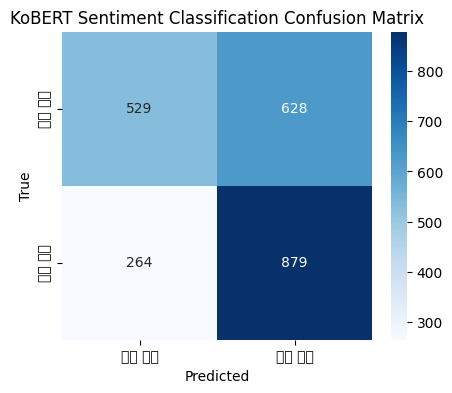

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["부정 예측", "긍정 예측"],
    yticklabels=["부정 실제", "긍정 실제"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KoBERT Sentiment Classification Confusion Matrix")
plt.show()

## 11. 모델 저장 및 재로드

In [21]:
save_dir = "./kobert-nsmc-finetuned"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print("Saved to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./kobert-nsmc-finetuned


In [23]:
%ls ./kobert-nsmc-finetuned

config.json        tokenizer_config.json  training_args.bin
model.safetensors  tokenizer.json


In [25]:
# Reload the model
loaded_tokenizer = AutoTokenizer.from_pretrained(save_dir, trust_remote_code=True)
loaded_model = AutoModelForSequenceClassification.from_pretrained(save_dir, trust_remote_code=True)
loaded_model.to(device)
loaded_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(8002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, 

## 12. 단일 문장 감정 예측

In [26]:
def predict_sentiment(text):
    inputs = loaded_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = loaded_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
    return {
        "text": text,
        "prediction": label_map[pred],
        "negative_prob": probs[0][0].item(),
        "positive_prob": probs[0][1].item()
    }

examples = [
    "정말 감동적인 영화였습니다. 다시 보고 싶어요.",
    "시간이 너무 아까웠고 배우들의 연기도 별로였습니다.",
    "스토리는 평범했지만 음악과 영상미가 좋았습니다.",
    "최악입니다. 돈이 아까워요.",
    "기대 이상으로 재미있었습니다."
]

for text in examples:
    result = predict_sentiment(text)
    print(f"입력 문장: {result['text']}")
    print(f"예측 감정: {result['prediction']}")
    print(f"부정 확률: {result['negative_prob']:.4f}")
    print(f"긍정 확률: {result['positive_prob']:.4f}")
    print("-" * 60)

입력 문장: 정말 감동적인 영화였습니다. 다시 보고 싶어요.
예측 감정: 긍정
부정 확률: 0.3849
긍정 확률: 0.6151
------------------------------------------------------------
입력 문장: 시간이 너무 아까웠고 배우들의 연기도 별로였습니다.
예측 감정: 긍정
부정 확률: 0.3789
긍정 확률: 0.6211
------------------------------------------------------------
입력 문장: 스토리는 평범했지만 음악과 영상미가 좋았습니다.
예측 감정: 긍정
부정 확률: 0.4082
긍정 확률: 0.5918
------------------------------------------------------------
입력 문장: 최악입니다. 돈이 아까워요.
예측 감정: 긍정
부정 확률: 0.3247
긍정 확률: 0.6753
------------------------------------------------------------
입력 문장: 기대 이상으로 재미있었습니다.
예측 감정: 긍정
부정 확률: 0.3328
긍정 확률: 0.6672
------------------------------------------------------------


In [28]:
user_text = input("감정을 분석할 한국어 문장을 입력하세요: ")
result = predict_sentiment(user_text)
print("입력 문장:", result["text"])
print("예측 감정:", result["prediction"])
print("부정 확률:", round(result["negative_prob"], 4))
print("긍정 확률:", round(result["positive_prob"], 4))

감정을 분석할 한국어 문장을 입력하세요: 오늘은 날씨가 비가와서 우울하네요.
입력 문장: 오늘은 날씨가 비가와서 우울하네요.
예측 감정: 긍정
부정 확률: 0.4168
긍정 확률: 0.5832


## 13. 오분류 샘플 분석

In [29]:
test_texts = []
for item in small_test:
    text = item["document"]
    label = item["label"]
    if text is not None and len(text.strip()) > 0:
        test_texts.append((text, label))

error_cases = []
for i, (text, true_label) in enumerate(test_texts[:len(y_pred)]):
    pred_label = y_pred[i]
    if true_label != pred_label:
        error_cases.append({
            "text": text,
            "true_label": label_map[true_label],
            "pred_label": label_map[pred_label]
        })

error_df = pd.DataFrame(error_cases)
print("오분류 개수:", len(error_df))
print("오분류 비율:", len(error_df) / len(y_pred))
error_df.head(20)

오분류 개수: 892
오분류 비율: 0.38782608695652177


,text,true_label,pred_label
0,놀라운건 시내 추격전에서 사람이 화살 맞고 죽는데도 시민들은 깜짝도 않하고 지나간다 ㅡㅡ,부정,긍정
1,3류독립영화보다못한영화 그냥보는 내내답답한 영화 시간낭비 스릴러냐이게 드라마지 10...,부정,긍정
2,공포는 있지만 줄거리는 그닥,부정,긍정
3,처음에 약간 긴장했으나 별루임...,부정,긍정
4,포스터부터 잼없어 보임...,부정,긍정
5,홍련의 화살 다음이야기를 영화로 만들던가 시나리오 개판에 미카사는 왠 태국여자 등장...,부정,긍정
6,이거 보고 한 동안 충격이었음.. 그래도 재미는 있어,긍정,부정
7,그린랜턴이라는 소재를 이따구로 날리냐,부정,긍정
8,어렵다 근데 포스터보면 알겟다 먼말인지 다시 쉽다 별거 아니다 그냥 기억만해라,긍정,부정
9,믿고 보는 제이슨스타뎀 다시한번 보답을 해주는구나 역시 경쾌하고 화려하다,긍정,부정
